# 04. Обучение моделей для прогноза шероховатости

Цель этапа: обучить модели регрессии для прогноза `roughness_ra` по режиму фрезерования и акустическим признакам.

Важно: делим данные по `condition_id`, чтобы один и тот же режим обработки не попал одновременно в train и test. Это дает более честную оценку.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "reports" / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Корень проекта:", PROJECT_ROOT)
print("Данные:", DATA_PROCESSED)
print("Модели:", MODELS_DIR)

Корень проекта: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project
Данные: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project\data\processed
Модели: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project\reports\models


## 1. Загружаем таблицу признаков

Берем файл `features.csv`, полученный на предыдущем этапе.


In [2]:
from modeling import get_feature_columns

features = pd.read_csv(DATA_PROCESSED / "features.csv")
feature_cols = get_feature_columns(features)

print("Размер features:", features.shape)
print("Целевая переменная: roughness_ra")
print("Количество признаков:", len(feature_cols))
print("Пропуски:", int(features.isna().sum().sum()))

display(features[["condition_id", "run_id", "feed_mm", "speed_rpm", "depth_mm", "roughness_ra"]].head())

Размер features: (319, 42)
Целевая переменная: roughness_ra
Количество признаков: 39
Пропуски: 0


,condition_id,run_id,feed_mm,speed_rpm,depth_mm,roughness_ra
0,f5_s250_d0.25,1,5.0,250,0.25,1.57
1,f5_s250_d0.25,2,5.0,250,0.25,1.57
2,f5_s250_d0.25,3,5.0,250,0.25,1.57
3,f5_s250_d0.25,4,5.0,250,0.25,1.57
4,f5_s250_d0.25,5,5.0,250,0.25,1.57


## 2. Разделяем train/test по режимам

В датасете шероховатость одинаковая для всех запусков одного режима. Поэтому случайный сплит по строкам был бы слишком оптимистичным.


In [3]:
from modeling import grouped_train_test_split

train, test = grouped_train_test_split(features, test_size=0.25, random_state=42)

print("Train:", train.shape, "строк,", train["condition_id"].nunique(), "режимов")
print("Test:", test.shape, "строк,", test["condition_id"].nunique(), "режимов")
print("Режимы в test:")
for condition in sorted(test["condition_id"].unique()):
    print("-", condition)

split_summary = pd.DataFrame({
    "part": ["train", "test"],
    "rows": [len(train), len(test)],
    "conditions": [train["condition_id"].nunique(), test["condition_id"].nunique()],
    "roughness_min": [train["roughness_ra"].min(), test["roughness_ra"].min()],
    "roughness_max": [train["roughness_ra"].max(), test["roughness_ra"].max()],
})
display(split_summary)

Train: (239, 42) строк, 12 режимов
Test: (80, 42) строк, 4 режимов
Режимы в test:
- f10_s250_d0.25
- f10_s250_d0.5
- f10_s500_d0.5
- f5_s500_d0.75


,part,rows,conditions,roughness_min,roughness_max
0,train,239,12,1.24,8.19
1,test,80,4,1.63,3.89


## 3. Кросс-валидация по группам

Сравниваем три модели: Linear Regression, Random Forest, Gradient Boosting. В кросс-валидации складки тоже формируются по `condition_id`.


,model,cv_MAE_mean,cv_MAE_std,cv_RMSE_mean,cv_RMSE_std,cv_R2_mean,cv_R2_std
0,Linear Regression,0.841240,0.437320,1.156536,0.675558,0.301554,0.188342
1,Gradient Boosting,0.957406,0.480668,1.197767,0.632901,0.182597,0.340381
2,Random Forest,1.157319,0.578913,1.481767,0.720395,-0.232394,0.310313


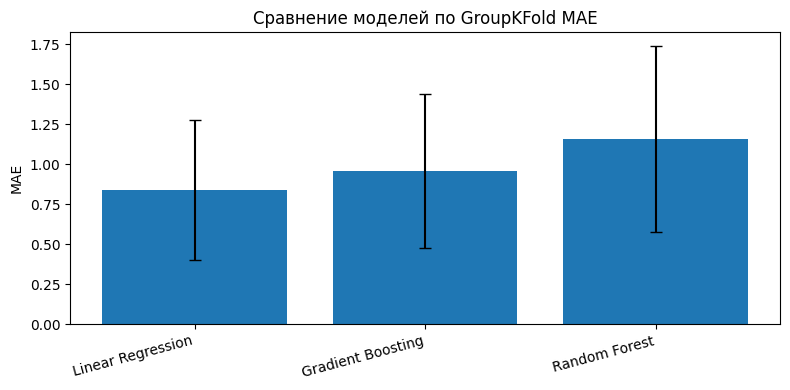

In [4]:
from modeling import cross_validate_models

cv_metrics = cross_validate_models(features, feature_cols, random_state=42, n_splits=4)
display(cv_metrics)

plt.figure(figsize=(8, 4))
plt.bar(cv_metrics["model"], cv_metrics["cv_MAE_mean"], yerr=cv_metrics["cv_MAE_std"], capsize=4)
plt.title("Сравнение моделей по GroupKFold MAE")
plt.ylabel("MAE")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_cv_mae.png", dpi=150)
plt.show()

## 4. Обучаем модели и оцениваем на test

После кросс-валидации обучаем модели на train и проверяем на отложенных режимах.


In [5]:
from modeling import fit_and_evaluate_models

metrics, predictions, fitted_models = fit_and_evaluate_models(
    train=train,
    test=test,
    feature_cols=feature_cols,
    random_state=42,
)

display(metrics)

best_model_name = metrics.iloc[0]["model"]
best_model = fitted_models[best_model_name]
print("Лучшая модель по test_MAE:", best_model_name)

,model,train_MAE,train_RMSE,train_R2,test_MAE,test_RMSE,test_R2
0,Linear Regression,0.255779,0.331819,0.973352,0.418521,0.607014,0.614625
1,Gradient Boosting,0.011272,0.016368,0.999935,1.115608,1.308314,-0.790232
2,Random Forest,0.044460,0.101934,0.997485,1.263811,1.436338,-1.157737


Лучшая модель по test_MAE: Linear Regression


,condition_id,run_id,feed_mm,speed_rpm,depth_mm,roughness_ra,model,prediction,abs_error
0,f5_s500_d0.75,1,5.0,500,0.75,1.63,Linear Regression,1.500724,0.129276
1,f5_s500_d0.75,1,5.0,500,0.75,1.63,Linear Regression,2.889123,1.259123
2,f5_s500_d0.75,2,5.0,500,0.75,1.63,Linear Regression,2.551605,0.921605
3,f5_s500_d0.75,4,5.0,500,0.75,1.63,Linear Regression,0.454044,1.175956
4,f5_s500_d0.75,5,5.0,500,0.75,1.63,Linear Regression,0.987419,0.642581
5,f5_s500_d0.75,6,5.0,500,0.75,1.63,Linear Regression,2.078411,0.448411
6,f5_s500_d0.75,7,5.0,500,0.75,1.63,Linear Regression,2.203942,0.573942
7,f5_s500_d0.75,8,5.0,500,0.75,1.63,Linear Regression,1.570460,0.059540
8,f5_s500_d0.75,9,5.0,500,0.75,1.63,Linear Regression,1.828760,0.198760
9,f5_s500_d0.75,10,5.0,500,0.75,1.63,Linear Regression,2.313237,0.683237


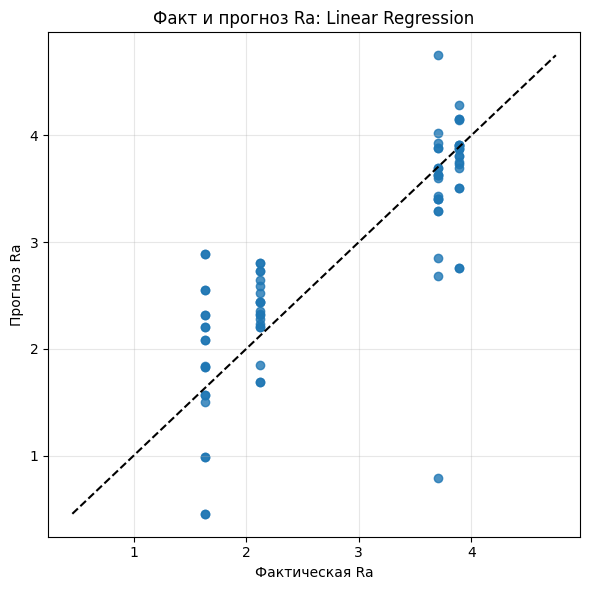

In [6]:
best_predictions = predictions[predictions["model"] == best_model_name].copy()

display(best_predictions.head(10))

plt.figure(figsize=(6, 6))
plt.scatter(best_predictions["roughness_ra"], best_predictions["prediction"], alpha=0.8)
min_value = min(best_predictions["roughness_ra"].min(), best_predictions["prediction"].min())
max_value = max(best_predictions["roughness_ra"].max(), best_predictions["prediction"].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="black")
plt.title(f"Факт и прогноз Ra: {best_model_name}")
plt.xlabel("Фактическая Ra")
plt.ylabel("Прогноз Ra")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_model_actual_vs_predicted.png", dpi=150)
plt.show()

## 5. Важность признаков

Смотрим, какие признаки модель считает наиболее важными. Для линейной модели используются модули коэффициентов, для деревьев - feature importance.


,feature,importance
0,sig_std,819.011421
1,sig_rms,804.937422
2,spec_power_total,129.948593
3,spec_power_500_2000,74.527182
4,spec_power_0_500,47.696135
5,sig_abs_mean,13.146573
6,spec_power_2000_8000,12.328490
7,spec_high_to_low_ratio,2.623984
8,xml_rms_max,2.312653
9,spec_rolloff85_hz,1.711509


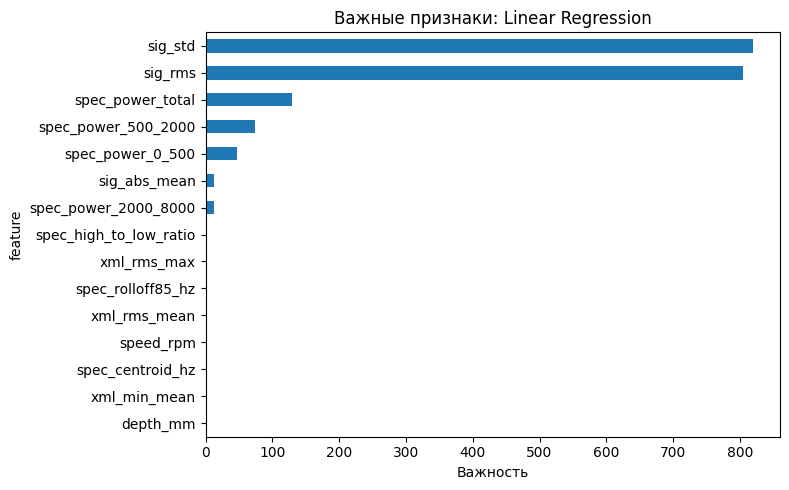

In [7]:
from modeling import feature_importance_table

importance = feature_importance_table(best_model, feature_cols)
display(importance.head(15))

plt.figure(figsize=(8, 5))
importance.head(15).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False,
    ax=plt.gca(),
)
plt.title(f"Важные признаки: {best_model_name}")
plt.xlabel("Важность")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_model_feature_importance.png", dpi=150)
plt.show()

## 6. Сохраняем артефакты

Сохраняем лучшую модель, метрики и прогнозы. Эти файлы пойдут в отчет и презентацию.


In [8]:
from modeling import save_model_artifacts

save_model_artifacts(
    output_dir=MODELS_DIR,
    best_model_name=best_model_name,
    best_model=best_model,
    feature_cols=feature_cols,
    metrics=metrics,
    cv_metrics=cv_metrics,
    predictions=predictions,
)

print("Артефакты сохранены в:", MODELS_DIR)
print("- best_roughness_model.joblib")
print("- model_metrics.csv")
print("- cv_metrics.csv")
print("- test_predictions.csv")

Артефакты сохранены в: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project\reports\models
- best_roughness_model.joblib
- model_metrics.csv
- cv_metrics.csv
- test_predictions.csv


## 7. Вывод по этапу

Модели обучены и сравнены. На малом числе уникальных режимов линейная модель может обобщаться лучше, чем более сложные ансамбли, потому что деревья легко запоминают режимы train. Это важно указать в отчете.
